# MSTT Tutorial: Classification with external Dataset

This tutorial demonstrates how to use MSTT for tabular classification for external datasets.  

In [219]:
import sys
from pathlib import Path

# Main root of repo MSTT
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [220]:
import os
import time
import numpy as np
import torch
from sklearn.metrics import classification_report
from sklearn.metrics import balanced_accuracy_score

import src.training as training
import src.testing as testing
import src.utils as utils
from src.model import MSTT

import torch.optim
import torch.nn as nn
from torch.utils.data import  DataLoader
from tqdm.auto import tqdm # Loading bar
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

## Configurations

In [221]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
NUM_WORKERS = min(4, os.cpu_count())
print("device:", DEVICE)
print("num_workers:", NUM_WORKERS)

device: cuda
num_workers: 4


In [222]:
torch.manual_seed(SEED) # for CPU

# If GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)  # si usas más de una GPU

# Deterministic options
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [223]:
MODEL_HYPERPARAMS = {
    "d_model": 256,
    "num_heads": 4,
    "hidden_dim_attmlp": 256 *2,  # d_model*2
    "hidden_dim_supmlp": 128,
    "num_learned_features": [[20,20], [10, 10]],
    "pos_norm": False,
    "bias_st_cat": True,
    "device" :  DEVICE, 
}

In [224]:
TRAINING_ARGS =  {
    "patience_early_stop":  10,
    "learning_rate" : 5e-4,
    "weight_decay" : 1e-4,
    "batch_size" : 64,
    "epochs" :  200
}

## Load and Preprocess data 

In [225]:
# Syntetic dataset
X, y = make_classification(
    n_samples = 5000,      
    n_features = 200,      
    n_informative = 40,    
    n_classes = 4,         
    random_state=42
)

print(f"Syntetic dataset: {X.shape}")  # Salida: (1000, 60)

Syntetic dataset: (5000, 200)


In [226]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)
print("Train dataset: ", X_train.shape)
print("Validation dataset: ", X_val.shape)
print("Test dataset: ", X_test.shape)

Train dataset:  (3825, 200)
Validation dataset:  (675, 200)
Test dataset:  (500, 200)


In [227]:
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)
X_val_norm = scaler.transform(X_val)

In [228]:
np.unique(y)

array([0, 1, 2, 3])

In [ ]:
# As syntetic data has only numerical features
num_idx =  list(range(200)) # List of the indexes of the numerical features
cat_idx = None
cat_cardinalities = []
n_classes = len(np.unique(y))
print('Number of classes:', n_classes)

Number of classes: 4


## Data Preparation and configuration

To facilitate data handling during training and evaluation, we first
organize the preprocessed datasets into a dictionary containing the
training, validation, and test splits.

Each split contains the target labels (`y`) and, depending on the
dataset, numerical (`x_cont`) and/or categorical (`x_cat`) features.

This structure allows MSTT to handle datasets with numerical features,
categorical features, or a combination of both.

The resulting dictionaries are then converted into PyTorch-compatible
datasets using the `CustomDictDataset` class.

In [230]:
# Verify the number of numerical and/or categorical features
total_features = X_train.shape[1]
n_cont_features = len(num_idx)
n_categorical_features = len(cat_idx)
train_idx = X_train.shape[0]
print("Number of features: ", total_features)
print("Number of numerical features: ", n_cont_features)
print("Number of categorical features: ", n_categorical_features)

Number of features:  200
Number of numerical features:  200
Number of categorical features:  0


In [231]:
#Organize the preprocessed data into a dictionary containing
# the training, validation, and test splits.
#
# Each split initially contains the corresponding target labels.
# Numerical and categorical features are added only if present
# in the dataset.
data_numpy = {
    "train": {"y": y_train},
    "val": {"y": y_val},
    "test": {"y": y_test},
}
# Add numerical features, if available.
# Numerical features are stored under the "x_cont" key.
if n_cont_features != 0:
    data_numpy["train"]["x_cont"] = X_train[:, num_idx].astype(np.float32)
    data_numpy["val"]["x_cont"] = X_val[:, num_idx].astype(np.float32)
    data_numpy["test"]["x_cont"] = X_test[:, num_idx].astype(np.float32)
# Add categorical features, if available.
# Categorical features are stored under the "x_cat" key
if n_categorical_features != 0:
    data_numpy["train"]["x_cat"] = (X_train[:, cat_idx]).astype(np.int64)
    data_numpy["val"]["x_cat"] = (X_val[:, cat_idx]).astype(np.int64)
    data_numpy["test"]["x_cat"] = (X_test[:, cat_idx]).astype(np.int64)

In [232]:
# Get task type (binary classification or multiclass) 
if n_classes == 2:
    task_type = "binary"
    binary_class_state = True
else:
    task_type = "multiclass"
    binary_class_state = False
    
print("Task type: ", task_type)

# The output size.
d_out = n_classes if task_type == "multiclass" else 1

Task type:  multiclass


In [233]:
# >>> Convert data to tensors.
dataset = {
    part: {k: torch.as_tensor(v) for k, v in data_numpy[part].items()}
    for part in data_numpy
}

if task_type != "multiclass":
    # Required by F.binary_cross_entropy_with_logits
    for part in dataset:
        dataset[part]["y"] = dataset[part]["y"].float()

## Create PyTorch Datasets and DataLoaders

The organized data is converted into PyTorch tensors and wrapped
using `CustomDictDataset`.

Finally, DataLoaders are created to provide mini-batches during
model training, validation, and testing.

In [234]:
train_dataset = utils.CustomDictDataset(dataset['train'],
                                        binary_class_state)

test_dataset = utils.CustomDictDataset(dataset['test'],
                                       binary_class_state)

val_dataset = utils.CustomDictDataset(dataset['val'],
                                      binary_class_state)

In [235]:
train_dataloader = DataLoader(train_dataset, 
                              batch_size = TRAINING_ARGS['batch_size'], 
                              shuffle = True,
                              num_workers = NUM_WORKERS,
                              pin_memory=True)

test_dataloader = DataLoader(test_dataset, 
                             batch_size = TRAINING_ARGS['batch_size'], 
                             shuffle = False,
                             num_workers = NUM_WORKERS,
                             pin_memory=True)

val_dataloader = DataLoader(val_dataset, 
                            batch_size = TRAINING_ARGS['batch_size'], 
                            shuffle = False,
                            num_workers = NUM_WORKERS,
                            pin_memory=True)

## Model Preparation

In [236]:
MODEL_HYPERPARAMS.update({
    "cat_cardinalities": cat_cardinalities,
    "num_features" : total_features,
    "output_dim_supmlp" : d_out,
})

In [237]:
mstt_model = MSTT(**MODEL_HYPERPARAMS).to(DEVICE)

## Training Configuration

In [238]:
early_stopping = training.EarlyStopping(patience = TRAINING_ARGS['patience_early_stop'], 
                                     verbose = True)

In [239]:
# Define optimizer
optimizer = torch.optim.AdamW(mstt_model.parameters(), 
                              lr = TRAINING_ARGS['learning_rate'], 
                              weight_decay = TRAINING_ARGS['weight_decay'],
                              betas=(0.9, 0.98))
#Define loss function
if task_type == "multiclass":
    criterion = nn.CrossEntropyLoss()
else:
    criterion = nn.BCEWithLogitsLoss()
print(criterion)

CrossEntropyLoss()


## Model Training

In [240]:
loss_train = []
acc_train = []
loss_val = []
acc_val = []
time_train = []

best_val_score = -float('inf')
patience = 7
epochs_without_improvement = 0
best_model_state = None  # To save best model

for epoch in tqdm(range(TRAINING_ARGS['epochs'])):
    print(f"Epoch: {epoch}\n--------" )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        epoch_start = time.time()
    else:
        epoch_start = time.time()
    train_loss,train_acc,_ = training.train(mstt_model,
                                         train_dataloader,
                                         criterion,
                                         optimizer,
                                         DEVICE,
                                         binary_class_state)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        epoch_end= time.time()
    else:
        epoch_end= time.time()

    val_loss,val_acc,_ = training.validation(mstt_model,
                                          val_dataloader,
                                          criterion,
                                          DEVICE,
                                          binary_class_state)

    loss_train.append(train_loss)
    acc_train.append(train_acc)
    loss_val.append(val_loss)
    acc_val.append(val_acc)
    training_time = round(epoch_end - epoch_start, 4)

    print(f"Epoch {epoch+1} training time: {training_time} seconds")
    time_train.append(training_time)

     # Check early stopping
    early_stopping.step(val_loss, val_acc, mstt_model)


    if early_stopping.should_stop:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch: 0
--------
Epoch train time: 1.4997101s
Train loss: 1.3717 | Train acc: 27.5276%
Val loss: 1.3082 | Val acc: 34.4387% | Time: 0.2162s
Epoch 1 training time: 1.5042 seconds
Epoch: 1
--------
Epoch train time: 1.4849440s
Train loss: 1.2868 | Train acc: 39.6184%
Val loss: 1.1675 | Val acc: 47.1244% | Time: 0.2128s
Epoch 2 training time: 1.4877 seconds
Epoch: 2
--------
Epoch train time: 1.5059052s
Train loss: 1.2239 | Train acc: 43.8472%
Val loss: 1.1368 | Val acc: 50.2997% | Time: 0.2418s
Epoch 3 training time: 1.5112 seconds
Epoch: 3
--------
Epoch train time: 1.7188362s
Train loss: 1.1522 | Train acc: 49.1548%
Val loss: 1.0901 | Val acc: 51.4875% | Time: 0.2644s
Epoch 4 training time: 1.7228 seconds
Epoch: 4
--------
Epoch train time: 1.5323405s
Train loss: 1.0925 | Train acc: 53.7830%
Val loss: 1.0384 | Val acc: 56.6283% | Time: 0.2132s
Epoch 5 training time: 1.536 seconds
Epoch: 5
--------
Epoch train time: 1.5150269s
Train loss: 1.0158 | Train acc: 58.6751%
Val loss: 1.0108 |

In [241]:
train_time = sum(time_train)/len(time_train)
print('Av training time: ', train_time)

Av training time:  1.472106896551724


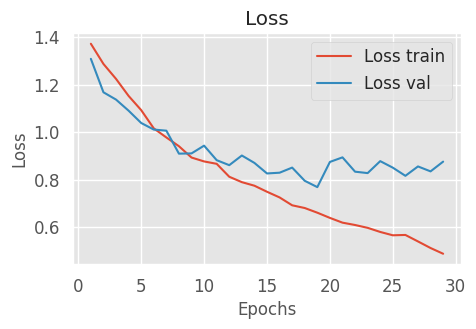

In [242]:
plt.figure(figsize=(5,3))
plt.plot(np.arange(1,len(loss_val)+1), loss_train)
plt.plot(np.arange(1,len(loss_val)+1), loss_val)
plt.title('Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Loss train', 'Loss val'])
plt.show()

In [243]:
mstt_model.load_state_dict(early_stopping.best_model_state)

<All keys matched successfully>

In [244]:
y_true,y_preds = testing.evaluate_model(mstt_model,
                                        test_dataloader,
                                        DEVICE,
                                        binary_class_state)

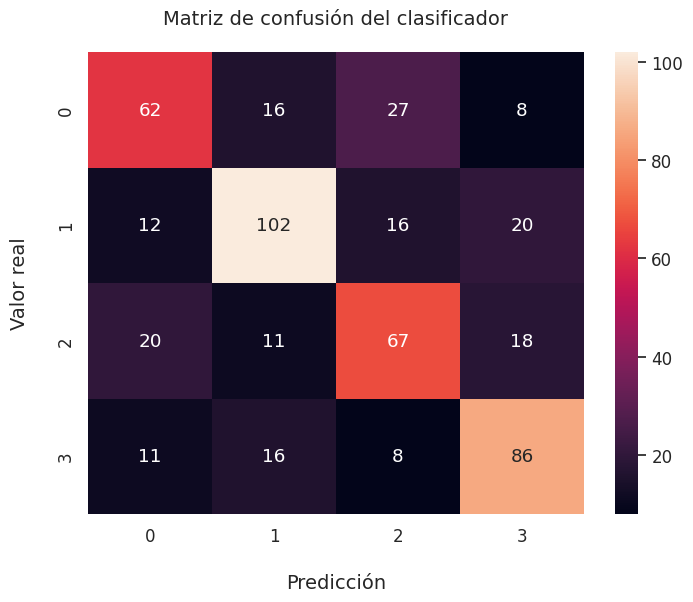

In [245]:
y_true = y_true.numpy()
y_preds = y_preds.numpy()
testing.plot_confussion_matrix(y_true,y_preds)

In [246]:
print(classification_report(y_true, y_preds))

              precision    recall  f1-score   support

           0       0.59      0.55      0.57       113
           1       0.70      0.68      0.69       150
           2       0.57      0.58      0.57       116
           3       0.65      0.71      0.68       121

    accuracy                           0.63       500
   macro avg       0.63      0.63      0.63       500
weighted avg       0.63      0.63      0.63       500



In [247]:
y_true,y_preds = testing.evaluate_model(mstt_model,train_dataloader,DEVICE,binary_class_state)
train_acc = balanced_accuracy_score(y_true, y_preds)

y_true,y_preds = testing.evaluate_model(mstt_model,val_dataloader,DEVICE,binary_class_state)
val_acc = balanced_accuracy_score(y_true, y_preds)

y_true,y_preds = testing.evaluate_model(mstt_model,test_dataloader,DEVICE,binary_class_state)
test_acc = balanced_accuracy_score(y_true, y_preds)

print('train_acc: ', train_acc, 'val_acc: ', val_acc,'test_acc: ', test_acc)

train_acc:  0.8165703185965312 val_acc:  0.7160545263778555 test_acc:  0.6292506437302814
